<xarray.Dataset> Size: 8GB
Dimensions:      (node: 2219482, nfaces: 4398700, nvertex: 3, nope: 1,
                  neta: 186, nbou: 73, nvel: 40294, time: 431)
Coordinates:
    x            (node) float64 18MB ...
    y            (node) float64 18MB ...
  * time         (time) datetime64[ns] 3kB 2024-09-23T12:15:00 ... 2024-09-27...
Dimensions without coordinates: node, nfaces, nvertex, nope, neta, nbou, nvel
Data variables:
    element      (nfaces, nvertex) int32 53MB ...
    adcirc_mesh  int32 4B ...
    nvdll        (nope) int32 4B ...
    ibtypee      (nope) int32 4B ...
    nbdv         (neta) int32 744B ...
    nvell        (nbou) int32 292B ...
    ibtype       (nbou) int32 292B ...
    nbvv         (nvel) int32 161kB ...
    depth        (node) float64 18MB ...
    swan_HS      (time, node) float64 8GB ...
Attributes: (12/50)
    _FillValue:         -99999.0
    model:              ADCIRC
    version:            v56.0.4
    git_hash:           5e5905d7e4b330b5c4c263d4253136c

C:\Users\csherwood\AppData\Local\miniforge3\envs\CRS\lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
C:\Users\csherwood\AppData\Local\miniforge3\envs\CRS\lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


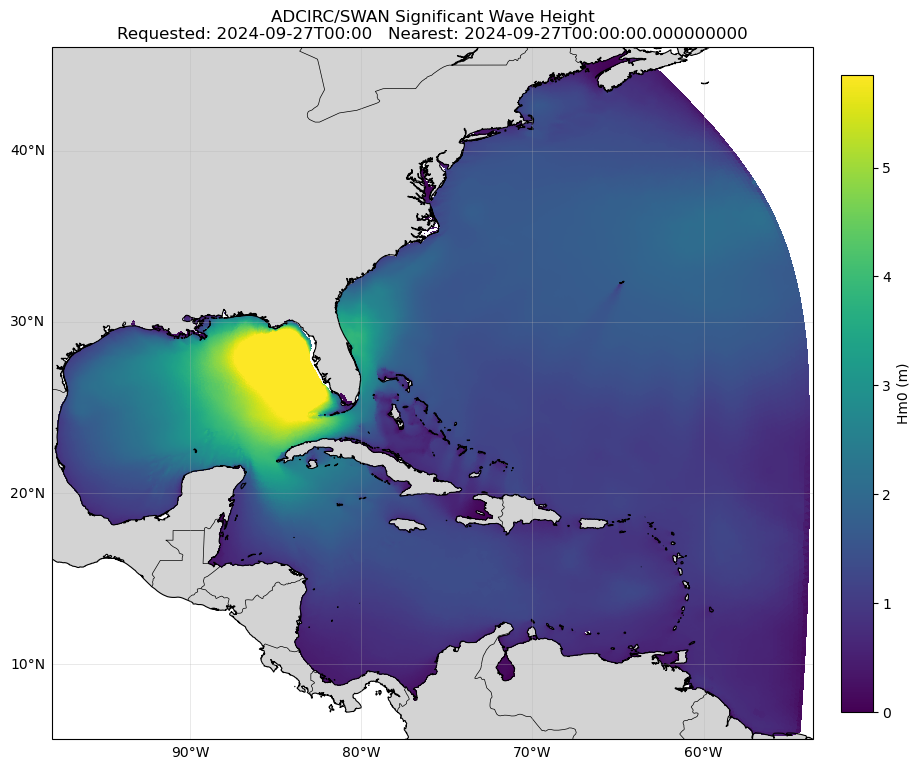

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

# Optional, but recommended for map context
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAVE_CARTOPY = True
except ImportError:
    HAVE_CARTOPY = False

# ============================================================
# USER SETTINGS
# ============================================================
ncfile = r"F:/crs/proj/2025_NOPP_comparison/helene_adcirc_model_results/bulk_wave_stats/allnodes_sig_waveheight_ts_swan_HS_63_orig.nc"
target_time = np.datetime64("2024-09-27T00:00")

vmin = 0.0
vmax = None          # set to fixed value if desired
cmap = "viridis"

# ============================================================
# OPEN DATA
# ============================================================
ds = xr.open_dataset(ncfile)
# Correct the time....model output has incorrect year of 2022.
ds = ds.assign_coords(time=ds["time"] + np.timedelta64(731, "D"))

sel = ds.sel(time=np.datetime64("2024-09-27T00:00"), method="nearest")
hs = sel["swan_HS"].values
tsel = sel["time"].values

print(ds)
print("\nAvailable times:")
print(ds["time"].values[:10])
print("...")
print(ds["time"].values[-10:])

# ============================================================
# SELECT NEAREST TIME
# ============================================================
itime = ds.indexes["time"].get_indexer([target_time], method="nearest")[0]
tsel = ds["time"].values[itime]

print(f"\nRequested time: {target_time}")
print(f"Nearest model time used: {tsel}")

# ============================================================
# EXTRACT VARIABLES
# ============================================================
x = ds["x"].values                    # (node,)
y = ds["y"].values                    # (node,)
hs = ds["swan_HS"].isel(time=itime).values   # (node,)
triangles = ds["element"].values      # (nfaces, 3)

# ADCIRC connectivity is usually 1-based; convert to 0-based for matplotlib
start_index = ds["element"].attrs.get("start_index", 1)
triangles = triangles.astype(np.int64) - start_index

# Mask bad wave heights
hs_plot = np.where(np.isfinite(hs), hs, np.nan)

# Optional auto vmax
if vmax is None:
    vmax = np.nanpercentile(hs_plot, 99)

# ============================================================
# BUILD TRIANGULATION
# ============================================================
tri = mtri.Triangulation(x, y, triangles=triangles)

# Mask triangles if any vertex has invalid value
tri_mask = np.any(~np.isfinite(hs_plot[triangles]), axis=1)
tri.set_mask(tri_mask)

# ============================================================
# PLOT
# ============================================================
fig = plt.figure(figsize=(10, 8))

if HAVE_CARTOPY:
    ax = plt.axes(projection=ccrs.PlateCarree())

    pcm = ax.tripcolor(
        tri,
        hs_plot,
        shading="flat",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree(),
    )

    ax.coastlines(resolution="10m", linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    valid = np.isfinite(hs_plot)
    if np.any(valid):
        lon_valid = x[valid]
        lat_valid = y[valid]
        pad_x = 0.2
        pad_y = 0.2
        ax.set_extent([
            np.nanmin(lon_valid) - pad_x,
            np.nanmax(lon_valid) + pad_x,
            np.nanmin(lat_valid) - pad_y,
            np.nanmax(lat_valid) + pad_y,
        ], crs=ccrs.PlateCarree())

else:
    ax = plt.axes()

    pcm = ax.tripcolor(
        tri,
        hs_plot,
        shading="flat",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xlabel("Longitude (degrees)")
    ax.set_ylabel("Latitude (degrees)")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)

cbar = plt.colorbar(pcm, ax=ax, shrink=0.85, pad=0.03)
cbar.set_label("Hm0 (m)")

ax.set_title(f"ADCIRC/SWAN Significant Wave Height\nRequested: {target_time}   Nearest: {str(tsel)}")

plt.tight_layout()
plt.show()